# Adaptive decoder: saved-run analysis

This notebook compares saved canonical YAML runs. Choose a primary run and optionally import selected decoder aliases from older runs through `additional_sources`. No sampling is needed. Set `run_path`, `filter`, and `group_by` below. The first `group_by` field controls line color; the second controls marker shape. Up to two fields are supported. The main plot, color legend and marker legend are three independent Matplotlib figures. Confidence bands are 99% Wilson intervals. Zero LER points show only the band. Run-wide color/marker assignments stay consistent under filtering and between LER and improvement-ratio plots.


In [2]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Reload local modules when this cell is rerun in an existing kernel.
import color_code_softoutput.simulation.config as workflow_config
import color_code_softoutput.analysis.color_correlated as color_correlated_analysis
importlib.reload(workflow_config)
importlib.reload(color_correlated_analysis)
ColorCorrelatedRun = color_correlated_analysis.ColorCorrelatedRun
import color_code_softoutput.analysis.color_correlated_comparison as comparison_analysis
importlib.reload(comparison_analysis)
ColorCorrelatedComparison = comparison_analysis.ColorCorrelatedComparison

# Primary run supplies the main data and preferred representative baselines.
run_path = PROJECT_ROOT / "results/bpmatching/26_09_29_23_27_44_9926fe3c"
# Import selected points from previous runs; use [] to analyze only the primary.
additional_sources = []
# additional_sources = [
#     {
#         "run_directory": PROJECT_ROOT / "cluster_results/26_09_29_14_07_21_d2d84062",
#         "filter": {"decoder_alias": "tesseract"},
#         # "alias_map": {"tesseract": "tesseract_previous"},
#     },
# ]
run = ColorCorrelatedComparison(run_path, additional_sources=additional_sources)
print("Run:", run.run_directory)
print("Start:", run.run_log["simulation_start_time"])
print("End:", run.run_log["simulation_end_time"])
print("Planned points:", len(run.catalog))
print("logical_error files present:", int(run.catalog["data_available"].sum()), "/", len(run.catalog))
print("Selected source runs:")
display(run.source_manifest)


Run: /home/quantum_teresheys/workspace/color_code_softoutput/results/bpmatching/26_09_29_23_27_44_9926fe3c
Start: 2026-09-29T23:27:44.624473+09:00
End: 2026-09-29T23:33:52.981986+09:00
Planned points: 36
logical_error files present: 36 / 36
Selected source runs:


[{'run_directory': '/home/quantum_teresheys/workspace/color_code_softoutput/results/bpmatching/26_09_29_23_27_44_9926fe3c',
  'filter': {},
  'alias_map': {},
  'selected_points': 36}]

## Confirm the configuration and available points

`run_log.json` supplies the saved configuration. The catalog lists every planned point and whether its `logical_error.parquet` is present. Aggregation also validates metric schemas, row counts, and shot indices.

`run.source_manifest` records the primary and imported run selections. The default imports only Tesseract from the older run. `source_run` and `data_directory` preserve each point's original files; duplicate alias/condition points and incompatible physical circuit options are rejected. `alias_map` can rename imported variants in this analysis without modifying saved logs.


In [3]:
display(run.run_log["config"])
display(run.catalog)

{'simulation': {'output_root': '/home/quantum_teresheys/workspace/color_code_softoutput/results/bpmatching',
  'shots': 10000,
  'workers': 6,
  'master_seed': 20260929,
  'buffer_shots': 2000,
  'verbose': True},
 'chunking': {'calibration_shots': 10,
  'target_chunk_seconds': 1.0,
  'min_chunk_shots': 1,
  'max_chunk_shots': 2000,
  'throughput_ema_alpha': 0.25},
 'sweep': {'distance': [5, 7, 9],
  'physical_error_rate': [0.03, 0.04, 0.05],
  'noise_model': ['depol'],
  'rounds': [2],
  'circuit_type': ['tri'],
  'cnot_schedule': ['tri_optimal']},
 'color_code_options': {'color_correlated_weight_basis': 'original_dem',
  'comparative_decoding': False,
  'exclude_non_essential_pauli_detectors': False,
  'perfect_first_syndrome_extraction': True,
  'superdense_circuit': False,
  'temp_bdry_type': 'Z'},
 'decoders': [{'type': 'concat_mwpm',
   'options': {},
   'decode_options': {'bp_predecoding': False,
    'colors': 'all',
    'compute_swim_distance': False,
    'full_output': False},

,source_run,source_priority,data_directory,decoder_alias,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM,concat_mwpm,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
1,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM,concat_mwpm,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
2,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM_perturbation,perturbation,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
3,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM_perturbation,perturbation,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
4,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM,concat_mwpm,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
5,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM,concat_mwpm,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
6,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM_perturbation,perturbation,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
7,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM_perturbation,perturbation,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
8,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM,concat_mwpm,tri,5,2,0.05,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
9,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM,concat_mwpm,tri,5,2,0.05,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True


## Choose conditions and line styles

Use scalar or list values in `filter`, for example `{"distance": [3, 5], "noise_model": "depol"}`. Available fields are `decoder_alias`, `decoder_type`, `circuit_type`, `distance`, `rounds`, `physical_error_rate`, `noise_model`, and `cnot_schedule`. Omitted filters include all values. Set `baseline_compare=True` to add one representative `decoder_type=baseline` per physical condition from advanced decoder `default_logical_error.parquet` files. Each baseline is paired with its own advanced decoder shots; decoder types can have independently sampled shots. Aliases are labels: check `decoder_type` and saved options for the actual method. Use `decoder_alias` to separate parameter variants of the same type. Include `decoder_alias` (or an explicitly selected unique `decoder_type`) in `group_by` when comparing the baseline. Every parameter that varies in the selected points (except physical error rate) must appear in `group_by` or be fixed by `filter`.

In [4]:
filter = {
    # "distance": [3, 5],
    # "decoder_alias": ["Stage2_original_perturbation", "Stage2_perturbed_perturbation"],
    # "decoder_type": ["perturbation", "tesseract"],
}
better_weight_filter = filter  # set a separate mapping to filter this table
effect_filter = filter  # set a separate mapping to filter this table
group_by = ["distance", "decoder_alias"]  # first: color; second: marker
baseline_compare = True  # one paired baseline per physical condition
yscale = "log"  # "log" or "linear"
plot_width = 7.4  # main axes width in inches
plot_height = 4.6  # main axes height in inches
# Legend layout is independent of the main plot.
legend_options = dict(fontsize=10, row_height=0.35, width=3.0, ncol=1)
save_figure = False

print("Selected points:")
display(run.select(filter))


Selected points:


,source_run,source_priority,data_directory,decoder_alias,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,expected_shots,point_directory,data_available
0,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM,concat_mwpm,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
1,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM,concat_mwpm,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
2,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM_perturbation,perturbation,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
3,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM_perturbation,perturbation,tri,5,2,0.03,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
4,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM,concat_mwpm,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
5,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM,concat_mwpm,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
6,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM_perturbation,perturbation,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
7,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM_perturbation,perturbation,tri,5,2,0.04,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
8,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,MWPM,concat_mwpm,tri,5,2,0.05,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True
9,/home/quantum_teresheys/workspace/color_code_s...,0,/home/quantum_teresheys/workspace/color_code_s...,BP_MWPM,concat_mwpm,tri,5,2,0.05,depol,tri_optimal,10000,/home/quantum_teresheys/workspace/color_code_s...,True


## Logical error rate versus physical error rate

The returned table includes shots, failures, LER, and 99% Wilson bounds. With baseline comparison enabled, `metric` identifies the saved file and `source_decoder_alias` and `source_decoder_type` identify the source experiment. Uniform-noise rates and bounds are per round. Zero-failure observations have no marker or line point: only the Wilson band remains, clipped at the visible lower axis limit on a log scale.

`figure`/`axes` describe the main plot. `ler_legends[field]` gives a separate `(figure, axes)` for each encoding. Adjust these independently before displaying or saving. Each legend has its field name as the title and lists individual values, without listing the Cartesian product. Main and legend figures are saved separately as PNG and PDF.


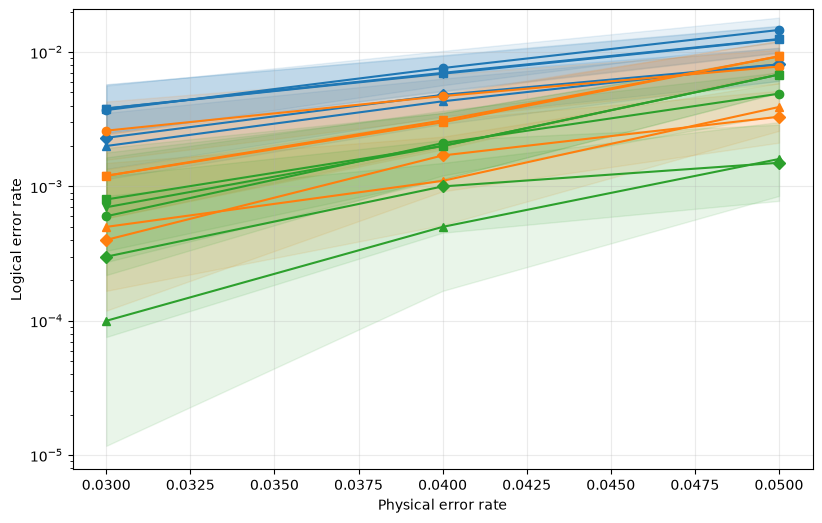

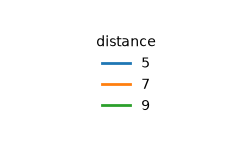

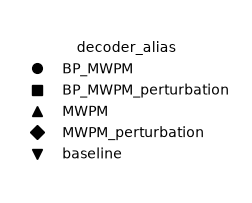

,distance,decoder_alias,decoder_type,source_decoder_alias,source_decoder_type,metric,source_run,physical_error_rate,shots,failures,logical_error_rate,ler_low,ler_high
0,5,BP_MWPM,concat_mwpm,BP_MWPM,concat_mwpm,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.03,10000,37,0.0037,0.002431,0.005627
1,5,BP_MWPM_perturbation,perturbation,BP_MWPM_perturbation,perturbation,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.03,10000,38,0.0038,0.002511,0.005747
2,5,MWPM,concat_mwpm,MWPM,concat_mwpm,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.03,10000,20,0.0020,0.001133,0.003527
3,5,MWPM_perturbation,perturbation,MWPM_perturbation,perturbation,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.03,10000,23,0.0023,0.001353,0.003907
4,5,baseline,baseline,BP_MWPM_perturbation,perturbation,default_logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.03,10000,38,0.0038,0.002511,0.005747
5,5,BP_MWPM,concat_mwpm,BP_MWPM,concat_mwpm,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.04,10000,76,0.0076,0.005667,0.010186
6,5,BP_MWPM_perturbation,perturbation,BP_MWPM_perturbation,perturbation,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.04,10000,70,0.0070,0.005155,0.009498
7,5,MWPM,concat_mwpm,MWPM,concat_mwpm,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.04,10000,43,0.0043,0.002912,0.006345
8,5,MWPM_perturbation,perturbation,MWPM_perturbation,perturbation,logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.04,10000,48,0.0048,0.003319,0.006938
9,5,baseline,baseline,BP_MWPM_perturbation,perturbation,default_logical_error,/home/quantum_teresheys/workspace/color_code_s...,0.04,10000,69,0.0069,0.005070,0.009383


In [5]:
figure, axes, ler_table = run.plot_ler(
    filter=filter,
    group_by=group_by,
    baseline_compare=baseline_compare,
    yscale=yscale,
    plot_width=plot_width,
    plot_height=plot_height,
)
ler_legends = run.plot_legends(ler_table, group_by=group_by, **legend_options)
# Customize independently here, for example:
# axes.set_title("...")
# ler_legends["distance"][0].set_size_inches(2.0, 2.5)
# ler_legends["decoder_alias"][1].get_legend().set_title("Decoder")
display(figure)
plt.close(figure)
for legend_figure, legend_axes in ler_legends.values():
    display(legend_figure)
    plt.close(legend_figure)
columns = ["distance", "decoder_alias", "decoder_type", "source_run", "physical_error_rate", "shots", "failures", "logical_error_rate", "ler_low", "ler_high"]
if baseline_compare:
    columns[3:3] = ["source_decoder_alias", "source_decoder_type", "metric"]
display(ler_table[columns])
if save_figure:
    output_dir = run.run_directory / "analysis"
    output_dir.mkdir(exist_ok=True)
    stem = "color_correlated_ler_with_baseline" if baseline_compare else "color_correlated_ler"
    figures = {stem: figure, **{f"{stem}_legend_{name}": pair[0] for name, pair in ler_legends.items()}}
    for name, saved_figure in figures.items():
        for extension in ("png", "pdf"):
            saved_figure.savefig(output_dir / f"{name}.{extension}", dpi=200, bbox_inches="tight")
    print("Saved figures to:", output_dir)


## LER improvement ratio versus code distance

Choose one `improvement_physical_error_rate` and optional `improvement_filter`. The ratio is **baseline LER / decoder LER**: a value above 1 means fewer logical failures. The dashed line at 1 denotes equal rates. The default x-axis is code distance; `x` can also be `rounds` or `physical_error_rate`.

Paired decoders use their own saved baseline. Decoders without paired metrics (for example Tesseract) use a representative baseline at the same physical conditions, including distance, rounds and noise model. `baseline_paired` and `baseline_point_directory` record that distinction. `baseline_source_decoder_alias` and `baseline_source_decoder_type` identify the experiment supplying the numerator. Filter these tables by `decoder_alias` to select a parameter variant. Infinite ratios (positive baseline and zero decoder LER) and undefined ratios (both zero) remain in the table and have no plotted estimate. No ratio confidence band is inferred from the marginal Wilson intervals.

The distance colors and decoder-alias markers match the LER figure. Both legends are independent figures and can be customized separately.


For imported Tesseract data, the representative baseline is taken from the primary run at the same physical conditions whenever available. `baseline_source_run` identifies that numerator; `source_run` identifies the Tesseract data. Such cross-run comparisons have `baseline_paired=False`. Paired decoders retain their own saved baselines. Different dates are never pooled into one shot sample.


In [5]:
improvement_filter = filter  # use a separate mapping to select these points
# Choose one saved physical error rate; edit this value as needed.
improvement_physical_error_rate = float(0.002)
improvement_x = "distance"
improvement_group_by = ["distance", "decoder_alias"]
improvement_legend_options = dict(fontsize=10, row_height=0.35, width=3.0, ncol=1)

ratio_figure, ratio_axes, ratio_table = run.plot_improvement_ratio(
    physical_error_rate=improvement_physical_error_rate,
    filter=improvement_filter,
    x=improvement_x,
    group_by=improvement_group_by,
    plot_width=plot_width,
    plot_height=plot_height,
)
ratio_legends = run.plot_legends(ratio_table, group_by=improvement_group_by, **improvement_legend_options)
# Customize ratio_axes and each ratio_legends[field] independently here.
display(ratio_figure)
plt.close(ratio_figure)
for legend_figure, legend_axes in ratio_legends.values():
    display(legend_figure)
    plt.close(legend_figure)
display(ratio_table[["distance", "decoder_alias", "decoder_type", "physical_error_rate", "logical_error_rate",
                     "baseline_logical_error_rate", "improvement_ratio", "baseline_paired",
                     "source_run", "baseline_source_run",
                     "baseline_source_decoder_alias", "baseline_source_decoder_type",
                     "baseline_point_directory"]])
if save_figure:
    output_dir = run.run_directory / "analysis"
    output_dir.mkdir(exist_ok=True)
    stem = f"color_correlated_improvement_ratio_p{improvement_physical_error_rate:g}"
    figures = {stem: ratio_figure, **{f"{stem}_legend_{name}": pair[0] for name, pair in ratio_legends.items()}}
    for name, saved_figure in figures.items():
        for extension in ("png", "pdf"):
            saved_figure.savefig(output_dir / f"{name}.{extension}", dpi=200, bbox_inches="tight")
    print("Saved figures to:", output_dir)


ValueError: No experiment points match the filters

## Correlated-decoding counts by experiment condition

Both tables retain `decoder_alias` and `decoder_type`; alias filters select individual parameter variants. The first table counts lower-weight candidates. In the second table, `effect_count` counts shots rescued relative to the paired baseline, `worsened_count` counts shots where the baseline succeeded but the selected decoder failed, and `net_effect_count = effect_count - worsened_count`. Positive net values mean fewer logical failures. These counts are blank for ordinary decoder points because paired baseline files are not produced. `shots` is the denominator for each count.

In [ ]:
display(run.better_weight_table(filter=better_weight_filter))
display(run.effect_table(filter=effect_filter))


,decoder_alias,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,source_run,data_directory,shots,better_weight_count
0,Stage2_original_perturbation,perturbation,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,146
1,Stage2_perturbed_perturbation,perturbation,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,97
2,concat_mwpm,color_correlated,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,97
3,tesseract,tesseract,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,<NA>
4,Stage2_original_perturbation,perturbation,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,256
5,Stage2_perturbed_perturbation,perturbation,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,285
6,concat_mwpm,color_correlated,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,187
7,tesseract,tesseract,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,<NA>
8,Stage2_original_perturbation,perturbation,tri,7,1,0.030,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,509
9,Stage2_perturbed_perturbation,perturbation,tri,7,1,0.030,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,523


,decoder_alias,decoder_type,circuit_type,distance,rounds,physical_error_rate,noise_model,cnot_schedule,source_run,data_directory,shots,effect_count,worsened_count,net_effect_count
0,Stage2_original_perturbation,perturbation,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,91,9,82
1,Stage2_perturbed_perturbation,perturbation,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,69,7,62
2,concat_mwpm,color_correlated,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,52,7,45
3,tesseract,tesseract,tri,7,1,0.020,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,<NA>,<NA>,<NA>
4,Stage2_original_perturbation,perturbation,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,166,25,141
5,Stage2_perturbed_perturbation,perturbation,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,191,15,176
6,concat_mwpm,color_correlated,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,106,16,90
7,tesseract,tesseract,tri,7,1,0.025,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,<NA>,<NA>,<NA>
8,Stage2_original_perturbation,perturbation,tri,7,1,0.030,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,344,51,293
9,Stage2_perturbed_perturbation,perturbation,tri,7,1,0.030,bitflip,tri_optimal,/home/quantum_teresheys/workspace/color_code_s...,/home/quantum_teresheys/workspace/color_code_s...,1000000,350,41,309


## Manuscript figure: stage-2 prior comparison

This optional export reads only the two stage-2 variants from the 14:38 saved run, independently of the main multi-run view above. It writes a main plot plus two separate vector PDF legends under `analysis/stage2_prior_comparison/`. This run uses **M=16**, alpha=1, distances 7/9/11 and 1,000,000 shots per point. No baseline is included in this comparison.

Adjust the main plot with `plot_width`/`plot_height`. Adjust legend text with `stage2_display_labels`, `legend.get_title().set_text(...)`, `label.set_fontsize(...)` and `legend.set_ncols(...)`. Adjust each legend canvas with `legend_figure.set_size_inches(width, height)`. These edits do not change the data or saved aliases. LaTeX can independently scale each PDF and control the horizontal/vertical spacing. The generated `figure_stage2_prior.tex` example illustrates that placement; copy the PDFs into your manuscript's `figures/` directory.


In [ ]:
from pathlib import Path
import matplotlib.pyplot as plt
from color_code_softoutput.analysis.color_correlated import ColorCorrelatedRun

stage2_run = ColorCorrelatedRun(
    PROJECT_ROOT / "cluster_results/26_09_28_14_38_26_779e2a31"
)
stage2_filter = {"decoder_alias": [
    "Stage2_original_perturbation", "Stage2_perturbed_perturbation",
]}
stage2_groups = ["distance", "decoder_alias"]

# Main plot dimensions; legend layout is independent.
stage2_figure, stage2_axes, stage2_table = stage2_run.plot_ler(
    filter=stage2_filter, group_by=stage2_groups, baseline_compare=False,
    plot_width=6.4, plot_height=4.0,
)
stage2_legends = stage2_run.plot_legends(
    stage2_table, group_by=stage2_groups,
    fontsize=11, row_height=0.35, width=3.0, ncol=3,
)

# Change display labels without changing the saved aliases or data.
stage2_display_labels = {
    "Stage2_original_perturbation": "Original prior",
    "Stage2_perturbed_perturbation": "Perturbed prior",
}
for field, (legend_figure, legend_axes) in stage2_legends.items():
    legend = legend_axes.get_legend()
    legend.get_title().set_text("Code distance" if field == "distance" else "Stage-2 prior")
    legend.get_title().set_fontsize(11)
    legend.set_ncols(3 if field == "distance" else 2)
    for label in legend.get_texts():
        old = label.get_text()
        label.set_text(f"$d={old}$" if field == "distance"
                       else stage2_display_labels.get(old, old))
        label.set_fontsize(11)
    legend_figure.set_size_inches(2.9 if field == "distance" else 4.5, 0.7)

stage2_output = stage2_run.run_directory / "analysis/stage2_prior_comparison"
stage2_output.mkdir(parents=True, exist_ok=True)
stage2_assets = {"stage2_prior_ler": stage2_figure,
                 **{f"stage2_prior_ler_legend_{field}": pair[0]
                    for field, pair in stage2_legends.items()}}
for name, saved_figure in stage2_assets.items():
    for extension in ("pdf", "png"):
        saved_figure.savefig(stage2_output / f"{name}.{extension}",
                             dpi=250, bbox_inches="tight", pad_inches=0.03)
print("Stage-2 figure assets:", stage2_output)
print("Data rows:", len(stage2_table))
display(stage2_figure)
for legend_figure, legend_axes in stage2_legends.values():
    display(legend_figure)
for figure in stage2_assets.values():
    plt.close(figure)


## Ensemble size comparison at p=0.03
Colors identify code distance; solid circles show perturbation ensembles, dotted lines the ordinary baseline and dashed lines Tesseract from the older run. Shading shows 99% Wilson intervals. The baseline is one deterministic representative from this run, without pooling shots. M includes the unperturbed member. Change `ensemble_physical_error_rate` below to select another p. All exports use zero padding. The TeX layout has no caption; add the caption in main.tex. Editing the output TeX and rerunning this cell recompiles your layout.


In [ ]:
import importlib
import color_code_softoutput.analysis.ensemble_size as ensemble_analysis
importlib.reload(ensemble_analysis)

# Independent of the run selected above. Reuse only Tesseract from the older run.
ensemble_run = ColorCorrelatedComparison(
    PROJECT_ROOT / "cluster_results/26_09_28_15_33_34_7f861167",
    additional_sources=[{
        "run_directory": PROJECT_ROOT / "cluster_results/26_09_28_14_38_26_779e2a31",
        "filter": {"decoder_alias": "tesseract"},
    }],
)
ensemble_physical_error_rate = 0.03
ensemble_figure, ensemble_axes, ensemble_table, ensemble_legends = (
    ensemble_analysis.plot_ensemble_size(
        ensemble_run, physical_error_rate=ensemble_physical_error_rate,
        plot_width=6.4, plot_height=4.0, fontsize=11,
    )
)
ensemble_output = ensemble_run.run_directory / "analysis/ensemble_size"
ensemble_output.mkdir(parents=True, exist_ok=True)
ensemble_assets = {"ensemble_size_ler": ensemble_figure,
                   **{f"ensemble_size_legend_{key}": pair[0]
                      for key, pair in ensemble_legends.items()}}
for name, fig in ensemble_assets.items():
    for extension in ("pdf", "png"):
        fig.savefig(ensemble_output / f"{name}.{extension}",
                    bbox_inches="tight", pad_inches=0, dpi=250)
ensemble_table.to_csv(ensemble_output / "ensemble_size_ler.csv", index=False)
# Create the layout once; later notebook reruns preserve your TeX edits.
ensemble_tex = ensemble_output / "ensemble_size_standalone.tex"
if not ensemble_tex.exists():
    ensemble_tex.write_text(
        (PROJECT_ROOT / "notes/support/ensemble_size_standalone.tex").read_text()
    )
# Compile the captionless composite vector PDF for main.tex.
import subprocess
subprocess.run(
    ["pdflatex", "-interaction=nonstopmode", "-halt-on-error", ensemble_tex.name],
    cwd=ensemble_output, check=True, capture_output=True, text=True,
)
print("Figure and legends:", ensemble_output)
display(ensemble_table[["distance", "decoder_alias", "ensemble_size",
                        "logical_error_rate", "source_run"]])
display(ensemble_figure)
for legend_fig, _ in ensemble_legends.values():
    display(legend_fig)
for fig in ensemble_assets.values():
    plt.close(fig)
